In [20]:
from pathlib import Path
from typing import Optional

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tqdm.auto import tqdm
tqdm.pandas()

In [21]:
PROJECT_ROOT = Path.cwd().parent
DATA_ROOT = PROJECT_ROOT / 'data' / 'images'
WIDE_ROOT = DATA_ROOT / 'orga_widecrop'
CROP_ROOT = DATA_ROOT / 'orga_cropping'
OUTPUT_DIR = PROJECT_ROOT / 'data' / 'manifests'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Racine du projet : {PROJECT_ROOT}')
print(f'Wide root : {WIDE_ROOT}')
print(f'Crop root : {CROP_ROOT}')

Racine du projet : c:\Users\Jules\Documents\IEES\idmybee
Wide root : c:\Users\Jules\Documents\IEES\idmybee\data\images\orga_widecrop
Crop root : c:\Users\Jules\Documents\IEES\idmybee\data\images\orga_cropping


## Autocrop

In [31]:
manifest = pd.read_csv(OUTPUT_DIR / 'manifest.csv')

usable_pairs = manifest[manifest['statut'] == 'paire_exploitable'].copy()
usable_pairs[['id', 'espece', 'role', 'statut']].head()

,id,espece,role,statut
0,FR15ABOM150820018_P1,Bombus_confusus,male,paire_exploitable
1,FR15ABOM150820018_P2,Bombus_confusus,male,paire_exploitable
2,FR15ABOM150820018_S1,Bombus_confusus,male,paire_exploitable
3,FR15ABOM150820018_S2,Bombus_confusus,male,paire_exploitable
4,FR15ABOM150820018_S3,Bombus_confusus,male,paire_exploitable


In [ ]:
def neutralize_grid(image: np.ndarray, blur_kernel: int = 5) -> np.ndarray:
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (blur_kernel, blur_kernel), 0)

    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=1)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)

    return thresh


def detect_main_bbox(image: np.ndarray, padding_ratio: float = 0.08) -> tuple[int, int, int, int]:
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)

    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=1)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not contours:
        h, w = image.shape[:2]
        return 0, 0, w, h

    candidates = []

    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        area = w * h
        if area < 1000:
            continue
        candidates.append((area, x, y, w, h))

    if not candidates:
        h, w = image.shape[:2]
        return 0, 0, w, h

    _, x, y, w, h = max(candidates, key=lambda item: item[0])
    pad_x = max(4, int(w * padding_ratio))
    pad_y = max(4, int(h * padding_ratio))

    return max(0, x - pad_x), max(0, y - pad_y), min(image.shape[1], x + w + pad_x), min(image.shape[0], y + h + pad_y)

In [ ]:
def detect_main_bbox_improved(
    image: np.ndarray, 
    padding_ratio: float = 0.08,
    adaptive_block_size: int = 31,
    morph_kernel_size: int = 21
) -> tuple[int, int, int, int]:
    """
    Détecte le bbox principal d'une aile avec améliorations :
    1. Seuillage adaptatif local (vs global OTSU) pour gérer les zones translucides vs pigmentées
    2. Fermeture morphologique agressive pour combler les trous internes
    3. Extraction de la plus grande composante connexe uniquement (élimine faux positifs isolés)
    4. Enveloppe convexe pour lissage naturel des contours de l'aile
    
    Args:
        image: Image BGR
        padding_ratio: Ratio de padding autour du bbox (8% par défaut)
        adaptive_block_size: Taille du voisinage pour seuillage adaptatif (doit être impair, 31 par défaut)
        morph_kernel_size: Taille du noyau morphologique pour closing (21 par défaut)
    
    Returns:
        (x1, y1, x2, y2): Coordonnées du bbox avec padding
    """
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)
    
    # 1. Seuillage adaptatif local plutôt que global (OTSU)
    # ADAPTIVE_THRESH_GAUSSIAN_C adapte le seuil localement en fonction du voisinage gaussien
    # Cela gère bien les zones translucides (contraste faible) vs zones pigmentées (contraste fort)
    thresh = cv2.adaptiveThreshold(
        gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV,
        adaptive_block_size, 2
    )
    
    # 2. Fermeture morphologique agressive pour combler les trous internes
    # Noyau elliptique de 21x21 (ou plus) avec 3 itérations
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (morph_kernel_size, morph_kernel_size))
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=3)
    
    # 3. Extraction de la plus grande composante connexe uniquement
    # Élimine directement les faux positifs isolés (e.g., en bas à droite du masque)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(thresh, connectivity=8)
    
    if num_labels <= 1:  # Seulement le background (label 0)
        h, w = image.shape[:2]
        return 0, 0, w, h
    
    # Ignorer le background (label 0), trouver la plus grande composante par aire
    largest_label = np.argmax(stats[1:, cv2.CC_STAT_AREA]) + 1
    component_mask = (labels == largest_label).astype(np.uint8) * 255
    
    # 4. Enveloppe convexe sur la plus grande composante
    # L'aile est une forme globalement convexe, ça remplit les trous internes naturellement
    contours, _ = cv2.findContours(component_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        cnt = contours[0]
        hull = cv2.convexHull(cnt)
        x, y, w, h = cv2.boundingRect(hull)
    else:
        h, w = image.shape[:2]
        return 0, 0, w, h
    
    # Ajout du padding
    pad_x = max(4, int(w * padding_ratio))
    pad_y = max(4, int(h * padding_ratio))
    
    return max(0, x - pad_x), max(0, y - pad_y), min(image.shape[1], x + w + pad_x), min(image.shape[0], y + h + pad_y)

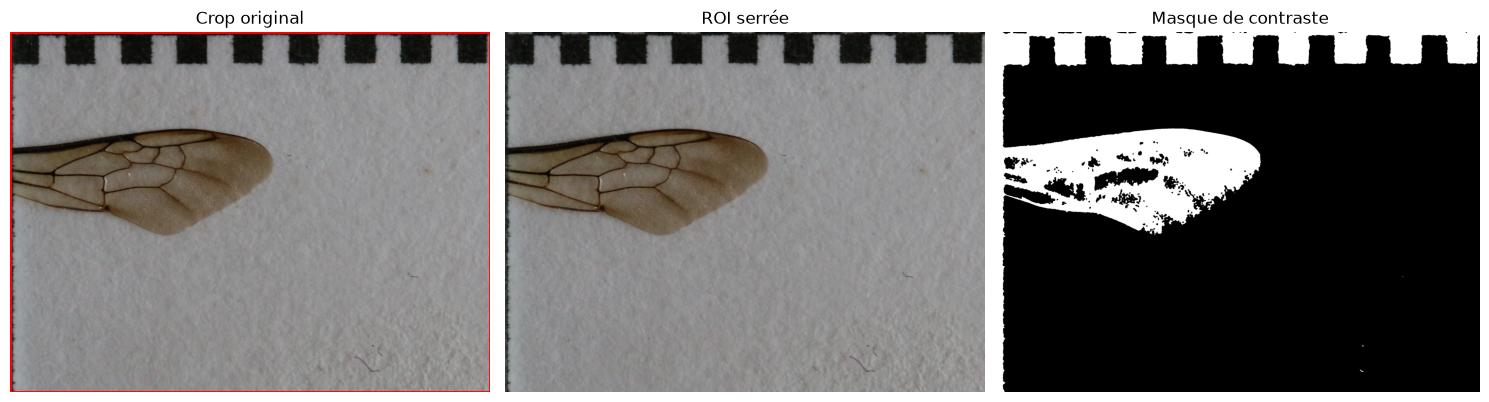

In [37]:
pair = usable_pairs.iloc[1]

wide_path = PROJECT_ROOT / pair['chemin_wide']
crop_path = PROJECT_ROOT / pair['chemin_crop_large']
wide = cv2.imread(str(wide_path), cv2.IMREAD_COLOR)
crop = cv2.imread(str(crop_path), cv2.IMREAD_COLOR)

if wide is None or crop is None:
    raise ValueError(f'Impossible de lire les images pour {pair["id"]}')

x, y, x2, y2 = detect_main_bbox(crop, padding_ratio=0)
roi = crop[y:y2, x:x2]
mask = neutralize_grid(crop)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
rect = plt.Rectangle((x, y), x2 - x, y2 - y, fill=False, edgecolor='red', linewidth=2)
axes[0].add_patch(rect)
axes[0].set_title('Crop original')
axes[1].imshow(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
axes[1].set_title('ROI serrée')
axes[2].imshow(mask, cmap='gray')
axes[2].set_title('Masque de contraste')

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
## Comparaison : ancien vs. nouveau detect_main_bbox

# Sélectionner quelques paires pour tester
test_indices = [1, 3, 7]  # Premiers exemples de paire_exploitable

fig, axes = plt.subplots(len(test_indices), 5, figsize=(20, 4 * len(test_indices)))
if len(test_indices) == 1:
    axes = axes.reshape(1, -1)

for row, idx in enumerate(test_indices):
    pair = usable_pairs.iloc[idx]
    crop_path = PROJECT_ROOT / pair['chemin_crop_large']
    crop = cv2.imread(str(crop_path), cv2.IMREAD_COLOR)
    
    if crop is None:
        print(f"Erreur : impossible de lire {crop_path}")
        continue
    
    # Masque original et amélioré
    mask_original = neutralize_grid(crop)
    
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)
    thresh = cv2.adaptiveThreshold(
        gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 31, 2
    )
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (21, 21))
    mask_improved = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=3)
    
    # Bounding boxes
    x1_old, y1_old, x2_old, y2_old = detect_main_bbox(crop, padding_ratio=0.08)
    x1_new, y1_new, x2_new, y2_new = detect_main_bbox_improved(crop, padding_ratio=0.08)
    
    # Affichage
    img_with_bbox_old = crop.copy()
    img_with_bbox_new = crop.copy()
    cv2.rectangle(img_with_bbox_old, (x1_old, y1_old), (x2_old, y2_old), (0, 255, 0), 2)
    cv2.rectangle(img_with_bbox_new, (x1_new, y1_new), (x2_new, y2_new), (0, 255, 0), 2)
    
    axes[row, 0].imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
    axes[row, 0].set_title(f"Crop original\n{pair['id']}")
    axes[row, 0].axis('off')
    
    axes[row, 1].imshow(mask_original, cmap='gray')
    axes[row, 1].set_title("Masque original\n(seuil OTSU global)")
    axes[row, 1].axis('off')
    
    axes[row, 2].imshow(mask_improved, cmap='gray')
    axes[row, 2].set_title("Masque amélioré\n(adaptatif local + closing)")
    axes[row, 2].axis('off')
    
    axes[row, 3].imshow(cv2.cvtColor(img_with_bbox_old, cv2.COLOR_BGR2RGB))
    axes[row, 3].set_title("Ancien bbox")
    axes[row, 3].axis('off')
    
    axes[row, 4].imshow(cv2.cvtColor(img_with_bbox_new, cv2.COLOR_BGR2RGB))
    axes[row, 4].set_title("Nouveau bbox\n(avec convex hull)")
    axes[row, 4].axis('off')

plt.tight_layout()
plt.show()

print("\nComparaison des bounding boxes (ancien vs. nouveau) :")
print("Ancien detect_main_bbox : seuil OTSU global + trouvé du plus grand contour")
print("Nouveau detect_main_bbox_improved : seuil adaptatif + composante connexe + convex hull")

In [ ]:
## Test de sensibilité : impact des hyperparamètres

# Tester différentes valeurs de adaptive_block_size et morph_kernel_size
pair = usable_pairs.iloc[1]
crop_path = PROJECT_ROOT / pair['chemin_crop_large']
crop = cv2.imread(str(crop_path), cv2.IMREAD_COLOR)

adaptive_sizes = [21, 31, 41]
morph_sizes = [15, 21, 27]

fig, axes = plt.subplots(len(adaptive_sizes), len(morph_sizes) + 1, figsize=(16, 12))

for i, adapt_size in enumerate(adaptive_sizes):
    # Colonne 0 : masque original pour comparaison
    if i == 0:
        axes[i, 0].imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
        axes[i, 0].set_title("Crop original")
        axes[i, 0].axis('off')
    else:
        axes[i, 0].axis('off')
    
    for j, morph_size in enumerate(morph_sizes):
        gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
        gray = cv2.GaussianBlur(gray, (5, 5), 0)
        
        # Adaptatif
        thresh = cv2.adaptiveThreshold(
            gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV,
            adapt_size, 2
        )
        
        # Closing morphologique
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (morph_size, morph_size))
        mask = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=3)
        
        axes[i, j + 1].imshow(mask, cmap='gray')
        axes[i, j + 1].set_title(f"adapt={adapt_size}, morph={morph_size}")
        axes[i, j + 1].axis('off')

plt.tight_layout()
plt.show()

print("Guidance : chercher la valeur qui remplit bien les trous translucides (haut de l'aile)")
print("sans dilater excessivement vers le papier (bas).")

In [ ]:
## Validation sur échantillon large : comparaison statistique

# Échantillon aléatoire de 50 paires exploitables
sample_size = min(50, len(usable_pairs))
sample_indices = np.random.choice(len(usable_pairs), sample_size, replace=False)

results = []

for idx in sample_indices:
    pair = usable_pairs.iloc[idx]
    crop_path = PROJECT_ROOT / pair['chemin_crop_large']
    crop = cv2.imread(str(crop_path), cv2.IMREAD_COLOR)
    
    if crop is None:
        continue
    
    x1_old, y1_old, x2_old, y2_old = detect_main_bbox(crop, padding_ratio=0.08)
    x1_new, y1_new, x2_new, y2_new = detect_main_bbox_improved(crop, padding_ratio=0.08)
    
    w_old = x2_old - x1_old
    h_old = y2_old - y1_old
    area_old = w_old * h_old
    
    w_new = x2_new - x1_new
    h_new = y2_new - y1_new
    area_new = w_new * h_new
    
    results.append({
        'id': pair['id'],
        'area_old': area_old,
        'area_new': area_new,
        'w_old': w_old,
        'w_new': w_new,
        'h_old': h_old,
        'h_new': h_new,
        'area_diff': area_new - area_old,
        'area_ratio': area_new / max(1, area_old)
    })

results_df = pd.DataFrame(results)

print(f"\n=== Comparaison sur {len(results_df)} paires ===\n")
print("Statistiques des bounding boxes :")
print(f"  Ancienne approche :")
print(f"    Aire moyenne: {results_df['area_old'].mean():.0f} px²")
print(f"    Aire médiane:  {results_df['area_old'].median():.0f} px²")
print(f"  Nouvelle approche :")
print(f"    Aire moyenne: {results_df['area_new'].mean():.0f} px²")
print(f"    Aire médiane:  {results_df['area_new'].median():.0f} px²")

print(f"\nDifférences (nouvelle - ancienne) :")
print(f"  Aire moyenne: {results_df['area_diff'].mean():.0f} px²")
print(f"  Aire min: {results_df['area_diff'].min():.0f} px²")
print(f"  Aire max: {results_df['area_diff'].max():.0f} px²")
print(f"  Ratio nouvelle/ancienne: {results_df['area_ratio'].mean():.3f} (moyenne)")

# Visualiser la distribution des changements
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(results_df['area_diff'], bins=20, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Différence d\'aire (px²)')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution des changements d\'aire\n(nouveau - ancien)')
axes[0].axvline(0, color='r', linestyle='--', linewidth=2, label='Pas de changement')
axes[0].legend()

axes[1].scatter(results_df['area_old'], results_df['area_new'], alpha=0.6)
axes[1].plot([results_df['area_old'].min(), results_df['area_old'].max()], 
             [results_df['area_old'].min(), results_df['area_old'].max()], 'r--', label='Pas de changement')
axes[1].set_xlabel('Aire ancienne (px²)')
axes[1].set_ylabel('Aire nouvelle (px²)')
axes[1].set_title('Correlation: ancien vs. nouveau bbox')
axes[1].legend()

plt.tight_layout()
plt.show()

# Montrer les cas extrêmes (plus grande augmentation/diminution)
print("\n=== Cas extrêmes ===")
print("\nPlus grandes augmentations d'aire (nouvelle > ancienne) :")
print(results_df.nlargest(3, 'area_diff')[['id', 'area_old', 'area_new', 'area_diff']])

print("\nPlus grandes diminutions d'aire (nouvelle < ancienne) :")
print(results_df.nsmallest(3, 'area_diff')[['id', 'area_old', 'area_new', 'area_diff']])

In [ ]:
## Application batch : détecter bbox sur toutes les paires exploitables (optionnel)

# Cette cellule génère les bounding boxes améliorées pour toutes les paires
# et les exporte pour utilisation dans phase 2 (localization in wide)

def apply_bbox_detection(
    row: pd.Series,
    crop_root: Path,
    method: str = 'improved'
) -> tuple[Optional[int], Optional[int], Optional[int], Optional[int]]:
    """
    Détecte le bbox pour une paire donnée.
    
    Args:
        row: Ligne du manifest
        crop_root: Racine des répertoires de crops
        method: 'original' ou 'improved'
    
    Returns:
        (x1, y1, x2, y2) ou (None, None, None, None) si erreur
    """
    crop_path = crop_root / row['chemin_crop_large']
    crop = cv2.imread(str(crop_path), cv2.IMREAD_COLOR)
    
    if crop is None:
        return None, None, None, None
    
    try:
        if method == 'improved':
            x1, y1, x2, y2 = detect_main_bbox_improved(crop, padding_ratio=0.08)
        else:
            x1, y1, x2, y2 = detect_main_bbox(crop, padding_ratio=0.08)
        return x1, y1, x2, y2
    except Exception as e:
        print(f"Erreur pour {row['id']}: {e}")
        return None, None, None, None

# Créer une copie du manifest pour les résultats
bbox_results = usable_pairs.copy()

# Appliquer la détection (progress_apply affiche une barre)
print("Détection des bounding boxes (approche améliorée)...")
bbox_results[['bbox_x1', 'bbox_y1', 'bbox_x2', 'bbox_y2']] = (
    bbox_results.progress_apply(
        lambda row: pd.Series(apply_bbox_detection(row, PROJECT_ROOT, method='improved')),
        axis=1
    )
)

# Ajouter des colonnes utiles
bbox_results['bbox_w'] = bbox_results['bbox_x2'] - bbox_results['bbox_x1']
bbox_results['bbox_h'] = bbox_results['bbox_y2'] - bbox_results['bbox_y1']
bbox_results['bbox_area'] = bbox_results['bbox_w'] * bbox_results['bbox_h']
bbox_results['bbox_valid'] = bbox_results['bbox_x1'].notna()

# Statistiques
print(f"\n=== Résultats détection (batch) ===")
print(f"Paires traitées: {len(bbox_results)}")
print(f"Bboxes valides: {bbox_results['bbox_valid'].sum()}")
print(f"Bboxes invalides: {(~bbox_results['bbox_valid']).sum()}")

print(f"\nAire des bboxes (pixels²):")
print(f"  Moyenne: {bbox_results['bbox_area'].mean():.0f}")
print(f"  Médiane: {bbox_results['bbox_area'].median():.0f}")
print(f"  Min: {bbox_results['bbox_area'].min():.0f}")
print(f"  Max: {bbox_results['bbox_area'].max():.0f}")

print(f"\nLargeur des bboxes (pixels):")
print(f"  Moyenne: {bbox_results['bbox_w'].mean():.0f}")
print(f"  Médiane: {bbox_results['bbox_w'].median():.0f}")

print(f"\nHauteur des bboxes (pixels):")
print(f"  Moyenne: {bbox_results['bbox_h'].mean():.0f}")
print(f"  Médiane: {bbox_results['bbox_h'].median():.0f}")

# Exporter les résultats
output_path = OUTPUT_DIR / 'bbox_results_improved.csv'
bbox_results.to_csv(output_path, index=False)
print(f"\n✓ Résultats exportés vers : {output_path}")